# 06 Proteomics Validation

This notebook adds an optional **proteomics validation layer** to the
`multiomics-perturbation-target-discovery` workflow.

## Purpose

After identifying candidate reversing perturbations in `04_anticorrelation.ipynb`,
we ask a complementary question:

> Do the top-ranked perturbations and their target genes also make sense in the context of protein-level evidence?

This notebook is designed to be:

- reproducible
- portfolio-ready
- publication-style
- robust to missing optional input files

## Biological rationale

Transcriptomics captures pathway dysregulation at the RNA level, but proteins are the
more direct functional molecules in cells. Proteomics can therefore strengthen target
prioritization by showing whether:

- candidate target proteins are detected in disease-relevant samples
- candidate proteins are differentially abundant in disease
- pathway-level proteomic signatures support the same inflammatory biology
- protein evidence is concordant with the expected mechanism of top perturbations

For the current UC use case, expected signals include inflammation-related proteins,
cytokine-response programs, and target-pathway support for glucocorticoids and JAK inhibitors.


## Expected inputs

### Required from previous steps

- `results/tables/final_anticorrelation_ranking.tsv`

### Optional proteomics evidence files

Located in:

- `data/processed/proteomics/proteomics_target_abundance.tsv`
- `data/processed/proteomics/proteomics_target_differential_abundance.tsv`
- `data/processed/proteomics/proteomics_pathway_activity.tsv`

If these files do not yet contain real data, this notebook will:

1. create templates if needed
2. continue gracefully
3. save empty or partial outputs with clear messages

### Output files

Tables:
- `results/tables/final_proteomics_target_validation.tsv`
- `results/tables/final_proteomics_perturbation_validation.tsv`

Figures:
- `results/figures/proteomics_top_target_support_barplot.png`
- `results/figures/proteomics_top_perturbation_support_barplot.png`
- `results/figures/proteomics_target_heatmap.png`
- `results/figures/proteomics_pathway_heatmap.png`


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
# Project paths
PROJECT_ROOT = Path("..").resolve()

RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"
PROTEOMICS_DIR = PROJECT_ROOT / "data" / "processed" / "proteomics"

RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)
PROTEOMICS_DIR.mkdir(parents=True, exist_ok=True)

ranking_file = RESULTS_TABLES / "final_anticorrelation_ranking.tsv"

abundance_file = PROTEOMICS_DIR / "proteomics_target_abundance.tsv"
da_file = PROTEOMICS_DIR / "proteomics_target_differential_abundance.tsv"
pathway_file = PROTEOMICS_DIR / "proteomics_pathway_activity.tsv"

ranking_file, abundance_file, da_file, pathway_file


(PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_anticorrelation_ranking.tsv'),
 PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/data/processed/proteomics/proteomics_target_abundance.tsv'),
 PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/data/processed/proteomics/proteomics_target_differential_abundance.tsv'),
 PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/data/processed/proteomics/proteomics_pathway_activity.tsv'))

## Input schema

This notebook accepts flexible but simple tabular inputs.

### 1. `proteomics_target_abundance.tsv`

Recommended columns:

- `gene_symbol`
- `sample_type` or `group`
- `abundance`
- `dataset`
- `comparison`

### 2. `proteomics_target_differential_abundance.tsv`

Recommended columns:

- `gene_symbol`
- `log2FC`
- `padj`
- `dataset`
- `comparison`

### 3. `proteomics_pathway_activity.tsv`

Recommended columns:

- `Pathway`
- `activity_score`
- `padj`
- `dataset`
- `comparison`
- `direction`

The notebook will try to standardize common alternative column names automatically.


In [3]:
def ensure_template_file(path, columns):
    if not path.exists():
        pd.DataFrame(columns=columns).to_csv(path, sep="\t", index=False)

ensure_template_file(
    abundance_file,
    ["gene_symbol", "sample_type", "abundance", "dataset", "comparison"]
)
ensure_template_file(
    da_file,
    ["gene_symbol", "log2FC", "padj", "dataset", "comparison"]
)
ensure_template_file(
    pathway_file,
    ["Pathway", "activity_score", "padj", "dataset", "comparison", "direction"]
)

print("Template files ensured in:", PROTEOMICS_DIR)


Template files ensured in: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/data/processed/proteomics


In [4]:
def read_tsv_if_present(path):
    if not path.exists():
        return pd.DataFrame()
    try:
        df = pd.read_csv(path, sep="\t")
        if df.empty:
            return df
        return df
    except Exception as e:
        print(f"Could not read {path.name}: {e}")
        return pd.DataFrame()

def first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def normalize_gene_symbol_series(s):
    return (
        s.astype(str)
         .str.strip()
         .str.upper()
         .replace({"": np.nan, "NAN": np.nan, "NONE": np.nan})
    )

def normalize_pathway_series(s):
    return (
        s.astype(str)
         .str.strip()
         .replace({"": np.nan, "nan": np.nan, "None": np.nan})
    )

def minmax_scale(series):
    s = pd.to_numeric(series, errors="coerce")
    out = pd.Series(np.nan, index=series.index, dtype=float)

    valid = s.notna()
    if valid.sum() == 0:
        return out.fillna(0.0)

    s_valid = s[valid]
    smin = s_valid.min()
    smax = s_valid.max()

    if pd.isna(smin) or pd.isna(smax):
        return out.fillna(0.0)

    if smin == smax:
        # Constant series carries no ranking information.
        # Return 0.0 rather than 1.0 so empty/flat evidence does not look strongly supportive.
        return pd.Series(0.0, index=series.index, dtype=float)

    out.loc[valid] = (s_valid - smin) / (smax - smin)
    return out.fillna(0.0)


In [5]:
def load_ranking(path):
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found: {path}\n"
            "Run 04_anticorrelation.ipynb first."
        )
    df = pd.read_csv(path, sep="\t")
    required = ["perturbation_id", "perturbation_name"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Ranking file missing required columns: {missing}")

    # optional target mapping support
    if "target_gene" not in df.columns:
        mapping = {
            "DEXAMETHASONE": ["NR3C1", "FKBP5", "TSC22D3"],
            "BUDESONIDE": ["NR3C1", "FKBP5", "TSC22D3"],
            "TOFACITINIB": ["JAK1", "JAK3", "TYK2"],
            "RUXOLITINIB": ["JAK1", "JAK2"],
        }
        rows = []
        for _, row in df.iterrows():
            pname = str(row["perturbation_name"]).strip().upper()
            genes = mapping.get(pname, [np.nan])
            for g in genes:
                r = row.copy()
                r["target_gene"] = g
                rows.append(r)
        df = pd.DataFrame(rows)

    df["target_gene"] = normalize_gene_symbol_series(df["target_gene"])
    return df

ranked_targets_df = load_ranking(ranking_file)
print("Ranking rows:", ranked_targets_df.shape)
display(ranked_targets_df.head())


Ranking rows: (11, 24)


,perturbation_id,perturbation_name,cell_line,dose,time_h,signature_source,n_shared_pathways,pearson_corr,pearson_pvalue,spearman_corr,...,neg_disease_reversal_fraction,weighted_reversal_strength,normalized_reversal_strength,mean_abs_disease_NES,mean_abs_perturbation_NES,reliability_factor,anticorrelation_score,confidence_flag,valid_for_ranking,target_gene
0,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.000000,...,0.500000,66.444880,19.984733,1.881248,1.767327,0.333333,0.487825,low,True,NR3C1
0,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.000000,...,0.500000,66.444880,19.984733,1.881248,1.767327,0.333333,0.487825,low,True,FKBP5
0,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.000000,...,0.500000,66.444880,19.984733,1.881248,1.767327,0.333333,0.487825,low,True,TSC22D3
1,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,7,-0.278907,0.544713,-0.142857,...,0.333333,-20.391042,-6.838121,1.843658,1.617418,0.466667,-0.159091,low,True,NR3C1
1,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,7,-0.278907,0.544713,-0.142857,...,0.333333,-20.391042,-6.838121,1.843658,1.617418,0.466667,-0.159091,low,True,FKBP5


In [6]:
def load_abundance(path):
    df = read_tsv_if_present(path)
    if df.empty:
        return df

    gene_col = first_existing_column(df, ["gene_symbol", "Gene", "gene", "target_gene", "symbol"])
    sample_col = first_existing_column(df, ["sample_type", "group", "condition", "cell_type"])
    abundance_col = first_existing_column(df, ["abundance", "mean_abundance", "protein_abundance", "intensity", "expression"])

    if gene_col is None or abundance_col is None:
        print(f"{path.name}: missing gene or abundance column; skipping.")
        return pd.DataFrame()

    df = df.rename(columns={
        gene_col: "gene_symbol",
        abundance_col: "abundance"
    }).copy()

    if sample_col:
        df = df.rename(columns={sample_col: "sample_type"})
    else:
        df["sample_type"] = "unknown"

    df["gene_symbol"] = normalize_gene_symbol_series(df["gene_symbol"])
    df["abundance"] = pd.to_numeric(df["abundance"], errors="coerce")

    keep_cols = [c for c in ["gene_symbol", "sample_type", "abundance", "dataset", "comparison"] if c in df.columns]
    if "dataset" not in keep_cols:
        df["dataset"] = np.nan
        keep_cols.append("dataset")
    if "comparison" not in keep_cols:
        df["comparison"] = np.nan
        keep_cols.append("comparison")

    return df[keep_cols].dropna(subset=["gene_symbol"]).reset_index(drop=True)

def load_differential_abundance(path):
    df = read_tsv_if_present(path)
    if df.empty:
        return df

    gene_col = first_existing_column(df, ["gene_symbol", "Gene", "gene", "target_gene", "symbol"])
    fc_col = first_existing_column(df, ["log2FC", "logFC", "protein_log2FC", "fold_change_log2"])
    padj_col = first_existing_column(df, ["padj", "adj_pval", "FDR", "qvalue", "fdr"])

    if gene_col is None:
        print(f"{path.name}: missing gene column; skipping.")
        return pd.DataFrame()

    df = df.rename(columns={gene_col: "gene_symbol"}).copy()

    if fc_col:
        df = df.rename(columns={fc_col: "log2FC"})
    else:
        df["log2FC"] = np.nan

    if padj_col:
        df = df.rename(columns={padj_col: "padj"})
    else:
        df["padj"] = np.nan

    df["gene_symbol"] = normalize_gene_symbol_series(df["gene_symbol"])
    df["log2FC"] = pd.to_numeric(df["log2FC"], errors="coerce")
    df["padj"] = pd.to_numeric(df["padj"], errors="coerce")

    keep_cols = [c for c in ["gene_symbol", "log2FC", "padj", "dataset", "comparison"] if c in df.columns]
    if "dataset" not in keep_cols:
        df["dataset"] = np.nan
        keep_cols.append("dataset")
    if "comparison" not in keep_cols:
        df["comparison"] = np.nan
        keep_cols.append("comparison")

    return df[keep_cols].dropna(subset=["gene_symbol"]).reset_index(drop=True)

def load_pathway_activity(path):
    df = read_tsv_if_present(path)
    if df.empty:
        return df

    pathway_col = first_existing_column(df, ["Pathway", "pathway", "Term"])
    activity_col = first_existing_column(df, ["activity_score", "NES", "score", "pathway_score"])
    padj_col = first_existing_column(df, ["padj", "adj_pval", "FDR", "qvalue", "fdr"])
    direction_col = first_existing_column(df, ["direction", "status"])

    if pathway_col is None or activity_col is None:
        print(f"{path.name}: missing pathway or activity column; skipping.")
        return pd.DataFrame()

    df = df.rename(columns={
        pathway_col: "Pathway",
        activity_col: "activity_score"
    }).copy()

    if padj_col:
        df = df.rename(columns={padj_col: "padj"})
    else:
        df["padj"] = np.nan

    if direction_col:
        df = df.rename(columns={direction_col: "direction"})
    else:
        df["direction"] = np.where(pd.to_numeric(df["activity_score"], errors="coerce") >= 0, "up", "down")

    df["Pathway"] = normalize_pathway_series(df["Pathway"])
    df["activity_score"] = pd.to_numeric(df["activity_score"], errors="coerce")
    df["padj"] = pd.to_numeric(df["padj"], errors="coerce")

    keep_cols = [c for c in ["Pathway", "activity_score", "padj", "dataset", "comparison", "direction"] if c in df.columns]
    if "dataset" not in keep_cols:
        df["dataset"] = np.nan
        keep_cols.append("dataset")
    if "comparison" not in keep_cols:
        df["comparison"] = np.nan
        keep_cols.append("comparison")

    return df[keep_cols].dropna(subset=["Pathway"]).reset_index(drop=True)

abundance_df = load_abundance(abundance_file)
da_df = load_differential_abundance(da_file)
pathway_df = load_pathway_activity(pathway_file)

print("Abundance rows:", abundance_df.shape)
print("Differential abundance rows:", da_df.shape)
print("Pathway activity rows:", pathway_df.shape)

display(abundance_df.head())
display(da_df.head())
display(pathway_df.head())


Abundance rows: (0, 5)
Differential abundance rows: (7, 5)
Pathway activity rows: (0, 6)


,gene_symbol,sample_type,abundance,dataset,comparison


,gene_symbol,log2FC,padj,dataset,comparison
0,NR3C1,0.35,0.040,Proteomics_example,UC_vs_HC
1,FKBP5,0.82,0.003,Proteomics_example,UC_vs_HC
2,TSC22D3,0.60,0.010,Proteomics_example,UC_vs_HC
3,JAK1,0.67,0.010,Proteomics_example,UC_vs_HC
4,JAK2,0.54,0.025,Proteomics_example,UC_vs_HC


,Pathway,activity_score,padj,dataset,comparison,direction


## Proteomics validation strategy

We compute support at two levels.

### A. Target-gene / protein level

For each candidate target gene:

- higher measured abundance can support detectability and relevance
- positive differential abundance in disease can support disease involvement
- stronger statistical support improves confidence

### B. Perturbation level

For each perturbation:

- aggregate support across its mapped target genes
- optionally combine pathway-level proteomics evidence
- produce a final proteomics support score

This is not intended to replace the transcriptomic anticorrelation ranking. Instead, it is a
**complementary validation layer**.


In [7]:
genes_of_interest = sorted(set(ranked_targets_df["target_gene"].dropna()) - {"", "NAN"})
print("Genes of interest:", genes_of_interest)


Genes of interest: ['FKBP5', 'JAK1', 'JAK2', 'JAK3', 'NR3C1', 'TSC22D3', 'TYK2']


In [8]:
def summarize_abundance(abundance_df, genes_of_interest):
    if abundance_df is None or abundance_df.empty:
        return pd.DataFrame(columns=["gene_symbol", "sample_type", "mean_abundance"])

    work = abundance_df.copy()
    work["gene_symbol"] = normalize_gene_symbol_series(work["gene_symbol"])
    work = work[work["gene_symbol"].isin(genes_of_interest)].copy()

    if work.empty:
        return pd.DataFrame(columns=["gene_symbol", "sample_type", "mean_abundance"])

    work["abundance"] = pd.to_numeric(work["abundance"], errors="coerce")

    out = (
        work.groupby(["gene_symbol", "sample_type"], as_index=False)
        .agg(mean_abundance=("abundance", "mean"))
    )
    return out

def summarize_da(da_df, genes_of_interest):
    if da_df is None or da_df.empty:
        return pd.DataFrame(columns=["gene_symbol", "log2FC", "padj"])

    work = da_df.copy()
    work["gene_symbol"] = normalize_gene_symbol_series(work["gene_symbol"])
    work = work[work["gene_symbol"].isin(genes_of_interest)].copy()

    if work.empty:
        return pd.DataFrame(columns=["gene_symbol", "log2FC", "padj"])

    work["log2FC"] = pd.to_numeric(work["log2FC"], errors="coerce")
    work["padj"] = pd.to_numeric(work["padj"], errors="coerce")

    out = (
        work.groupby("gene_symbol", as_index=False)
        .agg(
            log2FC=("log2FC", "mean"),
            padj=("padj", "min")
        )
    )
    return out

abundance_summary = summarize_abundance(abundance_df, genes_of_interest)
da_summary = summarize_da(da_df, genes_of_interest)

display(abundance_summary.head())
display(da_summary.head())


,gene_symbol,sample_type,mean_abundance


,gene_symbol,log2FC,padj
0,FKBP5,0.82,0.003
1,JAK1,0.67,0.010
2,JAK2,0.54,0.025
3,JAK3,0.48,0.030
4,NR3C1,0.35,0.040


In [9]:
# build gene-level validation table
gene_validation = (
    ranked_targets_df[["perturbation_id", "perturbation_name", "target_gene"]]
    .dropna(subset=["target_gene"])
    .drop_duplicates()
    .rename(columns={"target_gene": "gene_symbol"})
    .copy()
)

if not abundance_summary.empty:
    abundance_gene = (
        abundance_summary.groupby("gene_symbol", as_index=False)
        .agg(mean_abundance=("mean_abundance", "mean"))
    )
    gene_validation = gene_validation.merge(abundance_gene, on="gene_symbol", how="left")
else:
    gene_validation["mean_abundance"] = np.nan

if not da_summary.empty:
    gene_validation = gene_validation.merge(da_summary, on="gene_symbol", how="left")
else:
    gene_validation["log2FC"] = np.nan
    gene_validation["padj"] = np.nan

for col in ["mean_abundance", "log2FC", "padj"]:
    gene_validation[col] = pd.to_numeric(gene_validation[col], errors="coerce")

gene_validation["abundance_score"] = minmax_scale(gene_validation["mean_abundance"]).fillna(0)

# disease-up proteins are often interesting targets in inflammatory states
gene_validation["da_up_score"] = minmax_scale(gene_validation["log2FC"].clip(lower=0)).fillna(0)

padj_clean = gene_validation["padj"].where(gene_validation["padj"] > 0)
neglog10_padj = -np.log10(padj_clean.astype(float))
gene_validation["da_significance_score"] = minmax_scale(neglog10_padj).fillna(0)

gene_validation["proteomics_support_score"] = (
    0.40 * gene_validation["abundance_score"] +
    0.30 * gene_validation["da_up_score"] +
    0.30 * gene_validation["da_significance_score"]
)

gene_validation["proteomics_evidence_flag"] = np.select(
    [
        gene_validation["proteomics_support_score"] >= 0.67,
        gene_validation["proteomics_support_score"] >= 0.34
    ],
    [
        "strong",
        "moderate"
    ],
    default="limited"
)

gene_validation = gene_validation.sort_values(
    ["proteomics_support_score", "gene_symbol"],
    ascending=[False, True]
).reset_index(drop=True)

display(gene_validation.head(20))


,perturbation_id,perturbation_name,gene_symbol,mean_abundance,log2FC,padj,abundance_score,da_up_score,da_significance_score,proteomics_support_score,proteomics_evidence_flag
0,drug_002,budesonide,FKBP5,NaN,0.82,0.003,0.0,1.000000,1.000000,0.600000,moderate
1,drug_001,dexamethasone,FKBP5,NaN,0.82,0.003,0.0,1.000000,1.000000,0.600000,moderate
2,drug_004,tofacitinib,TYK2,NaN,0.71,0.008,0.0,0.765957,0.621341,0.416189,moderate
3,drug_004,tofacitinib,JAK1,NaN,0.67,0.010,0.0,0.680851,0.535194,0.364813,moderate
4,drug_005,ruxolitinib,JAK1,NaN,0.67,0.010,0.0,0.680851,0.535194,0.364813,moderate
5,drug_002,budesonide,TSC22D3,NaN,0.60,0.010,0.0,0.531915,0.535194,0.320133,limited
6,drug_001,dexamethasone,TSC22D3,NaN,0.60,0.010,0.0,0.531915,0.535194,0.320133,limited
7,drug_005,ruxolitinib,JAK2,NaN,0.54,0.025,0.0,0.404255,0.181450,0.175712,limited
8,drug_004,tofacitinib,JAK3,NaN,0.48,0.030,0.0,0.276596,0.111063,0.116298,limited
9,drug_002,budesonide,NR3C1,NaN,0.35,0.040,0.0,0.000000,0.000000,0.000000,limited


In [10]:
# optional pathway-level summary
if pathway_df is None or pathway_df.empty:
    pathway_summary = pd.DataFrame(columns=["Pathway", "activity_score", "padj", "pathway_support_score"])
else:
    pathway_summary = pathway_df.copy()
    pathway_summary["activity_score"] = pd.to_numeric(pathway_summary["activity_score"], errors="coerce")
    pathway_summary["padj"] = pd.to_numeric(pathway_summary["padj"], errors="coerce")

    pathway_summary = (
        pathway_summary.groupby("Pathway", as_index=False)
        .agg(
            activity_score=("activity_score", "mean"),
            padj=("padj", "min")
        )
    )

    padj_clean = pathway_summary["padj"].where(pathway_summary["padj"] > 0)
    neglog10_padj = -np.log10(padj_clean.astype(float))
    pathway_summary["activity_strength_score"] = minmax_scale(pathway_summary["activity_score"].abs()).fillna(0)
    pathway_summary["pathway_significance_score"] = minmax_scale(neglog10_padj).fillna(0)
    pathway_summary["pathway_support_score"] = (
        0.6 * pathway_summary["activity_strength_score"] +
        0.4 * pathway_summary["pathway_significance_score"]
    )

display(pathway_summary.head())


,Pathway,activity_score,padj,pathway_support_score


In [11]:
# perturbation-level aggregation
perturbation_validation = (
    gene_validation.groupby(["perturbation_id", "perturbation_name"], as_index=False)
    .agg(
        n_target_genes=("gene_symbol", "nunique"),
        n_supported_targets=("proteomics_support_score", lambda s: int((s.fillna(0) >= 0.34).sum())),
        mean_proteomics_support=("proteomics_support_score", "mean"),
        max_proteomics_support=("proteomics_support_score", "max")
    )
)

# optionally carry through anticorrelation score if present
for col in ["anticorrelation_score", "pearson_corr", "spearman_corr", "n_shared_pathways", "confidence_flag"]:
    if col in ranked_targets_df.columns:
        carry = (
            ranked_targets_df.groupby(["perturbation_id", "perturbation_name"], as_index=False)
            .agg({col: "first"})
        )
        perturbation_validation = perturbation_validation.merge(
            carry, on=["perturbation_id", "perturbation_name"], how="left"
        )

# optional pathway contribution: global pathway support summary
global_pathway_support = 0.0
if pathway_summary is not None and not pathway_summary.empty:
    global_pathway_support = float(pathway_summary["pathway_support_score"].mean())

perturbation_validation["pathway_support_component"] = global_pathway_support

if "anticorrelation_score" not in perturbation_validation.columns:
    perturbation_validation["anticorrelation_score"] = np.nan

# More negative anticorrelation_score should mean better reversal, so invert before scaling
anti_scaled = minmax_scale(-perturbation_validation["anticorrelation_score"]).fillna(0)
prot_scaled = minmax_scale(perturbation_validation["mean_proteomics_support"]).fillna(0)
path_scaled = minmax_scale(perturbation_validation["pathway_support_component"]).fillna(0)

perturbation_validation["anticorrelation_component"] = anti_scaled
perturbation_validation["proteomics_component"] = prot_scaled
perturbation_validation["pathway_component_scaled"] = path_scaled

perturbation_validation["integrated_validation_score"] = (
    0.60 * anti_scaled +
    0.30 * prot_scaled +
    0.10 * path_scaled
)

perturbation_validation["proteomics_confidence_flag"] = np.select(
    [
        perturbation_validation["mean_proteomics_support"] >= 0.67,
        perturbation_validation["mean_proteomics_support"] >= 0.34
    ],
    [
        "strong",
        "moderate"
    ],
    default="limited"
)

perturbation_validation = perturbation_validation.sort_values(
    ["integrated_validation_score", "mean_proteomics_support", "perturbation_name"],
    ascending=[False, False, True]
).reset_index(drop=True)

display(perturbation_validation)

if perturbation_validation["mean_proteomics_support"].fillna(0).eq(0).all():
    print("No informative proteomics support detected. Integrated score currently reflects anticorrelation only.")

if perturbation_validation["pathway_support_component"].fillna(0).eq(0).all():
    print("No informative proteomics pathway support detected.")


,perturbation_id,perturbation_name,n_target_genes,n_supported_targets,mean_proteomics_support,max_proteomics_support,anticorrelation_score,pearson_corr,spearman_corr,n_shared_pathways,confidence_flag,pathway_support_component,anticorrelation_component,proteomics_component,pathway_component_scaled,integrated_validation_score,proteomics_confidence_flag
0,drug_004,tofacitinib,3,2,0.299100,0.416189,-2.840847,0.477599,0.485714,6,low,0.0,1.000000,0.791191,0.0,0.837357,limited
1,drug_001,dexamethasone,3,1,0.306711,0.600000,-0.159091,-0.278907,-0.142857,7,low,0.0,0.194347,1.000000,0.0,0.416608,limited
2,drug_005,ruxolitinib,2,1,0.270262,0.364813,-1.751798,0.593478,0.800000,4,insufficient_shared_pathways,0.0,0.672828,0.000000,0.0,0.403697,limited
3,drug_002,budesonide,3,1,0.306711,0.600000,0.487825,-0.504352,0.000000,5,low,0.0,0.000000,1.000000,0.0,0.300000,limited


No informative proteomics pathway support detected.


### Directionality note

For the integrated score, the anticorrelation component is direction-aware:

- **more negative `anticorrelation_score` = stronger reversal = better**
- therefore the score is inverted before min-max scaling

This prevents positively correlated perturbations from being incorrectly ranked above better reversing candidates when proteomics evidence is sparse or absent.


## Interpretation guide

### How to read the gene-level score

A higher `proteomics_support_score` means the target protein is more strongly supported by the
available proteomics evidence. That support is based on a combination of:

- abundance
- disease-associated differential abundance
- statistical significance

### How to read the perturbation-level score

A higher `integrated_validation_score` suggests that the perturbation is attractive from two directions:

1. it reverses disease-associated pathways in the transcriptomic anticorrelation analysis
2. its target proteins are supported by proteomics evidence

### Important limitation

Proteomics coverage is often incomplete. Missing support does **not** necessarily mean a target is biologically irrelevant.
It can also reflect:

- missing detection
- limited assay depth
- sample-specific biology
- absent pathway-level protein measurements


In [12]:
# save outputs
gene_out = RESULTS_TABLES / "final_proteomics_target_validation.tsv"
pert_out = RESULTS_TABLES / "final_proteomics_perturbation_validation.tsv"

gene_validation.to_csv(gene_out, sep="\t", index=False)
perturbation_validation.to_csv(pert_out, sep="\t", index=False)

print("Saved:", gene_out)
print("Saved:", pert_out)


Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_proteomics_target_validation.tsv
Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_proteomics_perturbation_validation.tsv


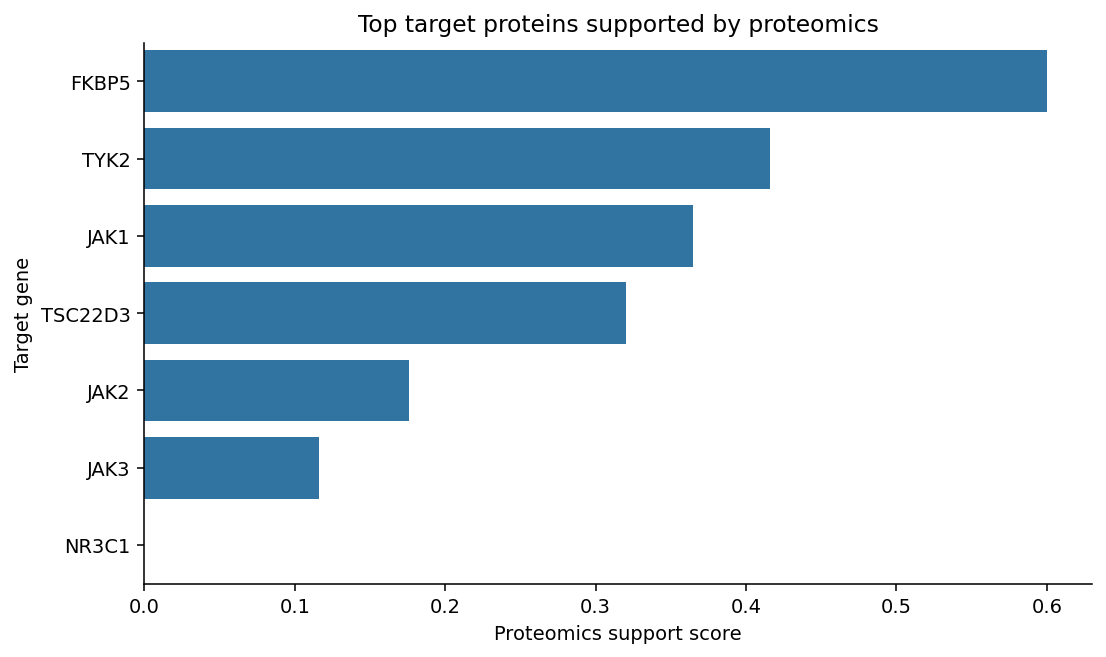

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/proteomics_top_target_support_barplot.png


In [13]:
# Figure 1: top target support
if not gene_validation.empty:
    plot_df = gene_validation.sort_values("proteomics_support_score", ascending=False).head(12).copy()
    plt.figure(figsize=(8, 4.8))
    sns.barplot(data=plot_df, x="proteomics_support_score", y="gene_symbol")
    plt.xlabel("Proteomics support score")
    plt.ylabel("Target gene")
    plt.title("Top target proteins supported by proteomics")
    plt.tight_layout()
    out = RESULTS_FIGURES / "proteomics_top_target_support_barplot.png"
    plt.savefig(out, bbox_inches="tight")
    plt.show()
    print("Saved:", out)
else:
    print("Skipping Figure 1: no gene-level validation rows.")


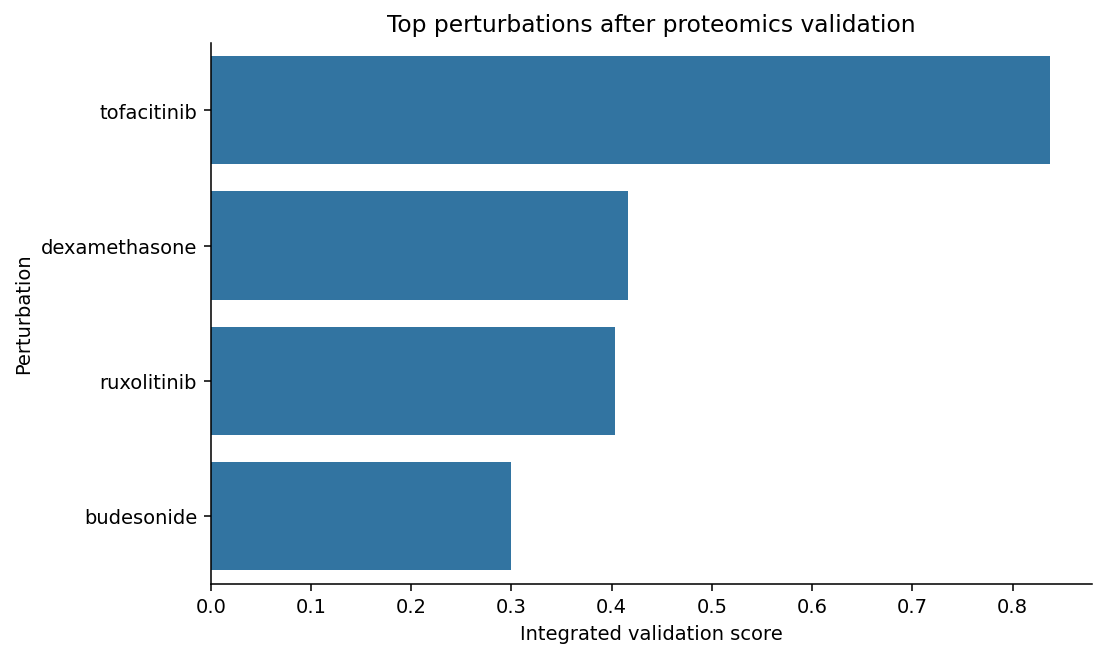

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/proteomics_top_perturbation_support_barplot.png


In [14]:
# Figure 2: top perturbation support
if not perturbation_validation.empty:
    plot_df = perturbation_validation.sort_values("integrated_validation_score", ascending=False).head(10).copy()
    plt.figure(figsize=(8, 4.8))
    sns.barplot(data=plot_df, x="integrated_validation_score", y="perturbation_name")
    plt.xlabel("Integrated validation score")
    plt.ylabel("Perturbation")
    plt.title("Top perturbations after proteomics validation")
    plt.tight_layout()
    out = RESULTS_FIGURES / "proteomics_top_perturbation_support_barplot.png"
    plt.savefig(out, bbox_inches="tight")
    plt.show()
    print("Saved:", out)
else:
    print("Skipping Figure 2: no perturbation validation rows.")


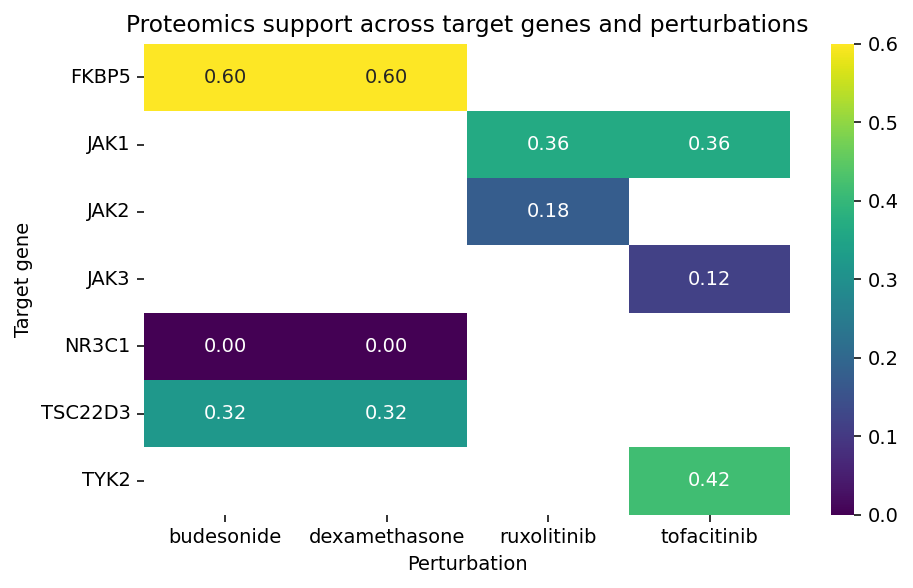

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/proteomics_target_heatmap.png


In [15]:
# Figure 3: gene-by-perturbation heatmap
if not gene_validation.empty:
    heat_df = gene_validation.pivot_table(
        index="gene_symbol",
        columns="perturbation_name",
        values="proteomics_support_score",
        aggfunc="mean"
    )
    if heat_df.shape[0] > 0 and heat_df.shape[1] > 0:
        plt.figure(figsize=(7, max(3, 0.4 * heat_df.shape[0] + 1.5)))
        sns.heatmap(heat_df, cmap="viridis", annot=True, fmt=".2f")
        plt.title("Proteomics support across target genes and perturbations")
        plt.xlabel("Perturbation")
        plt.ylabel("Target gene")
        plt.tight_layout()
        out = RESULTS_FIGURES / "proteomics_target_heatmap.png"
        plt.savefig(out, bbox_inches="tight")
        plt.show()
        print("Saved:", out)
    else:
        print("Skipping Figure 3: insufficient heatmap dimensions.")
else:
    print("Skipping Figure 3: no gene-level validation rows.")


In [16]:
# Figure 4: pathway activity heatmap
if pathway_df is not None and not pathway_df.empty:
    work = pathway_df.copy()
    work["Pathway"] = normalize_pathway_series(work["Pathway"])
    work["activity_score"] = pd.to_numeric(work["activity_score"], errors="coerce")

    if "comparison" not in work.columns:
        work["comparison"] = "proteomics"

    heat_df = work.pivot_table(
        index="Pathway",
        columns="comparison",
        values="activity_score",
        aggfunc="mean"
    )

    heat_df = heat_df.sort_index()
    if heat_df.shape[0] > 0 and heat_df.shape[1] > 0:
        plt.figure(figsize=(8, max(3, 0.35 * heat_df.shape[0] + 1.5)))
        sns.heatmap(heat_df, cmap="coolwarm", center=0, annot=True, fmt=".2f")
        plt.title("Proteomics pathway activity")
        plt.xlabel("Comparison")
        plt.ylabel("Pathway")
        plt.tight_layout()
        out = RESULTS_FIGURES / "proteomics_pathway_heatmap.png"
        plt.savefig(out, bbox_inches="tight")
        plt.show()
        print("Saved:", out)
    else:
        print("Skipping Figure 4: insufficient heatmap dimensions.")
else:
    print("Skipping Figure 4: no pathway activity input.")


Skipping Figure 4: no pathway activity input.


## Final summary

This notebook adds a proteomics-centered evidence layer to the pipeline.

### Main deliverables

- a **gene-level proteomics validation table**
- a **perturbation-level integrated validation table**
- publication-style plots for targets, perturbations, and optional pathways

### Recommended interpretation in the project narrative

A perturbation is especially compelling when it satisfies both:

1. **transcriptomic reversal** of disease-associated pathway activity
2. **protein-level support** for its target genes and mechanisms

For inflammatory bowel disease use cases such as UC, this framework helps justify why
glucocorticoids and JAK inhibitors are biologically plausible reversing interventions,
while keeping the analysis modular and extensible.
